In [2]:
# Cell 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Cell 2 - Load Dataset
df = pd.read_csv('../data/Fraud Detection Dataset.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Dataset loaded successfully!
Shape: (51000, 12)
Total rows: 51000
Total columns: 12


In [5]:
# Cell 3 - First Look
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== LAST 5 ROWS ===")
display(df.tail())

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

=== FIRST 5 ROWS ===


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0



=== LAST 5 ROWS ===


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0



=== COLUMN NAMES ===
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


In [6]:
# Cell 4 - Data Types and Info
print("=== DATASET INFO ===")
df.info()

print("\n=== DATA TYPES OF EACH COLUMN ===")
print(df.dtypes)

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-nu

In [7]:
# Cell 5 - Missing Values
print("=== MISSING VALUES IN EACH COLUMN ===")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent.round(2)
})

print(missing_df[missing_df['Missing Count'] > 0])

print(f"\nTotal missing values in entire dataset: {df.isnull().sum().sum()}")

=== MISSING VALUES IN EACH COLUMN ===
                     Missing Count  Missing Percent
Transaction_Amount            2520             4.94
Time_of_Transaction           2552             5.00
Device_Used                   2473             4.85
Location                      2547             4.99
Payment_Method                2469             4.84

Total missing values in entire dataset: 12561


=== FRAUD DISTRIBUTION ===
Fraudulent
0    48490
1     2510
Name: count, dtype: int64

Normal transactions: 48490
Fraud transactions:  2510

Fraud percentage: 4.92%


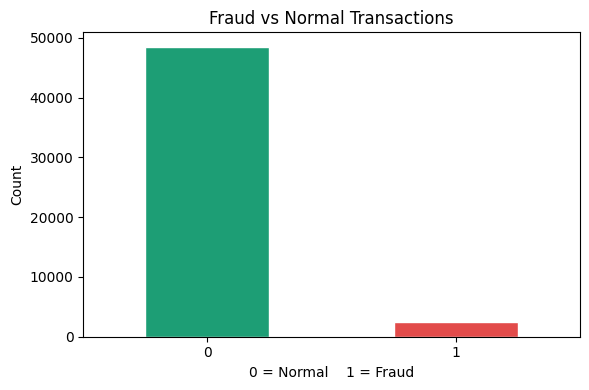

In [8]:
# Cell 6 - Fraud vs Normal Distribution
print("=== FRAUD DISTRIBUTION ===")
print(df['Fraudulent'].value_counts())
print()
print(f"Normal transactions: {df['Fraudulent'].value_counts()[0]}")
print(f"Fraud transactions:  {df['Fraudulent'].value_counts()[1]}")
print()
fraud_percent = (df['Fraudulent'].value_counts()[1] / len(df)) * 100
print(f"Fraud percentage: {fraud_percent:.2f}%")

# Chart
plt.figure(figsize=(6, 4))
colors = ['#1D9E75', '#E24B4A']
df['Fraudulent'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Fraud vs Normal Transactions')
plt.xlabel('0 = Normal    1 = Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Cell 7 - Basic Statistics
print("=== BASIC STATISTICS ===")
display(df.describe())

=== BASIC STATISTICS ===


,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


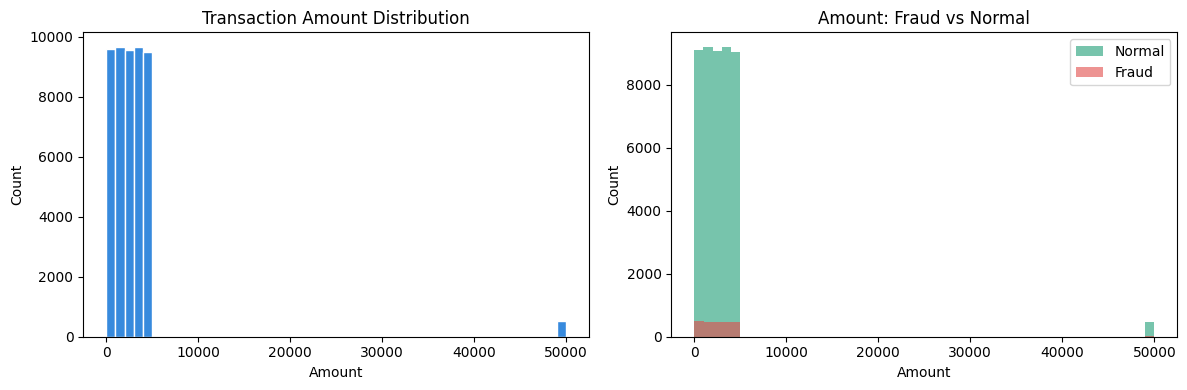

In [10]:
# Cell 8 - Transaction Amount Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Distribution of amount
axes[0].hist(df['Transaction_Amount'].dropna(), bins=50, color='#378ADD', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

# Chart 2: Amount by fraud vs normal
fraud_amounts = df[df['Fraudulent'] == 1]['Transaction_Amount'].dropna()
normal_amounts = df[df['Fraudulent'] == 0]['Transaction_Amount'].dropna()

axes[1].hist(normal_amounts, bins=50, alpha=0.6, color='#1D9E75', label='Normal')
axes[1].hist(fraud_amounts, bins=50, alpha=0.6, color='#E24B4A', label='Fraud')
axes[1].set_title('Amount: Fraud vs Normal')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

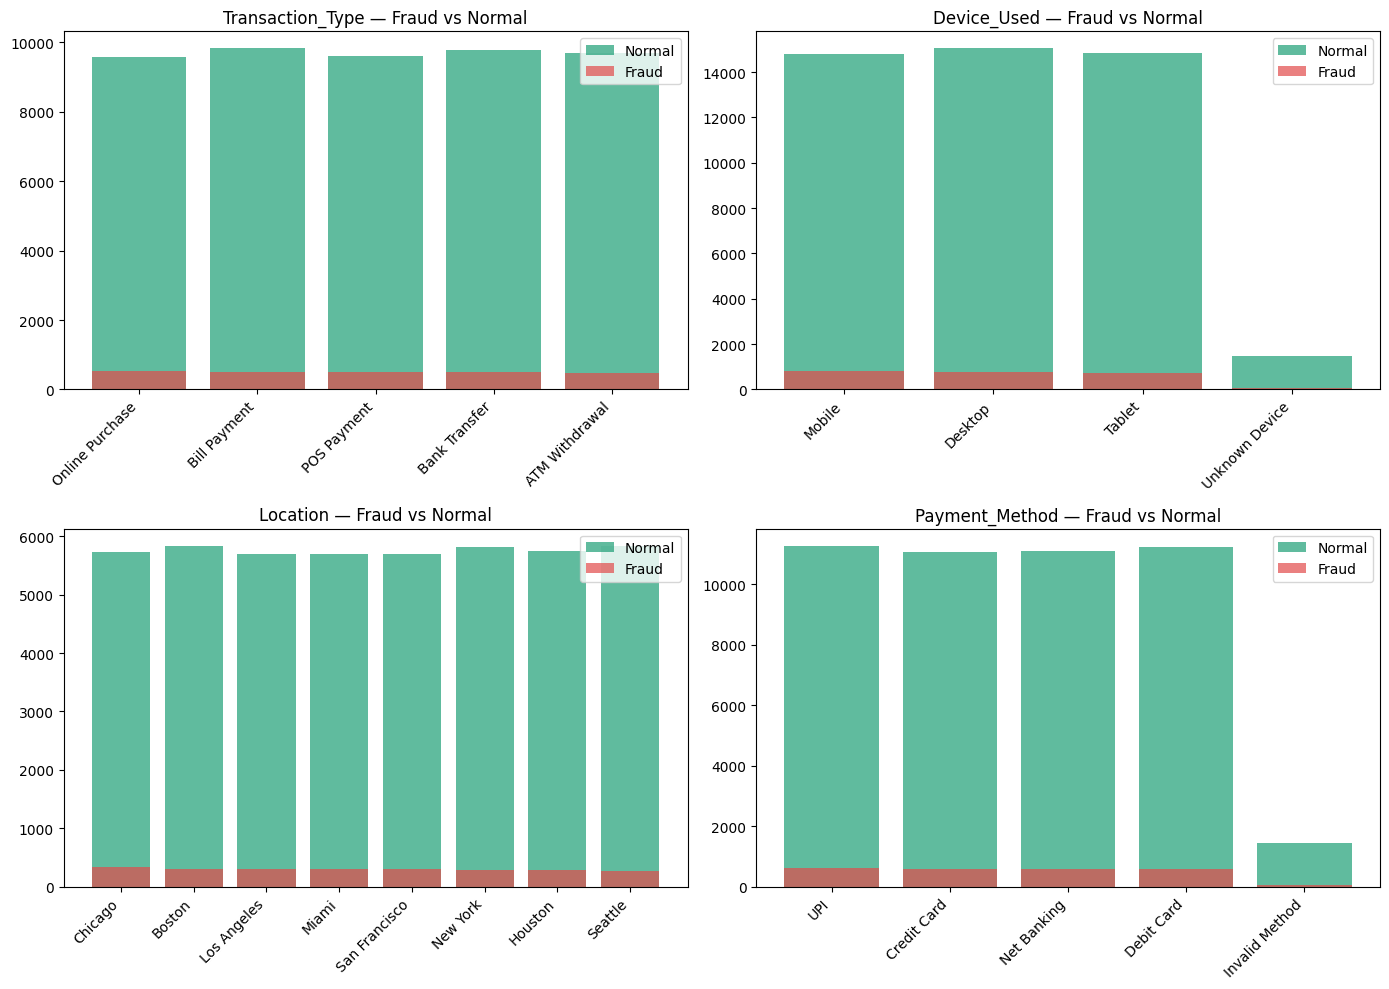

In [11]:
# Cell 9 - Categorical Column Analysis
cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    fraud_counts = df[df['Fraudulent'] == 1][col].value_counts()
    normal_counts = df[df['Fraudulent'] == 0][col].value_counts()

    x = range(len(fraud_counts))
    axes[i].bar(x, normal_counts.reindex(fraud_counts.index).fillna(0),
                label='Normal', color='#1D9E75', alpha=0.7)
    axes[i].bar(x, fraud_counts.values,
                label='Fraud', color='#E24B4A', alpha=0.7)
    axes[i].set_title(f'{col} — Fraud vs Normal')
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(fraud_counts.index, rotation=45, ha='right')
    axes[i].legend()

plt.tight_layout()
plt.show()

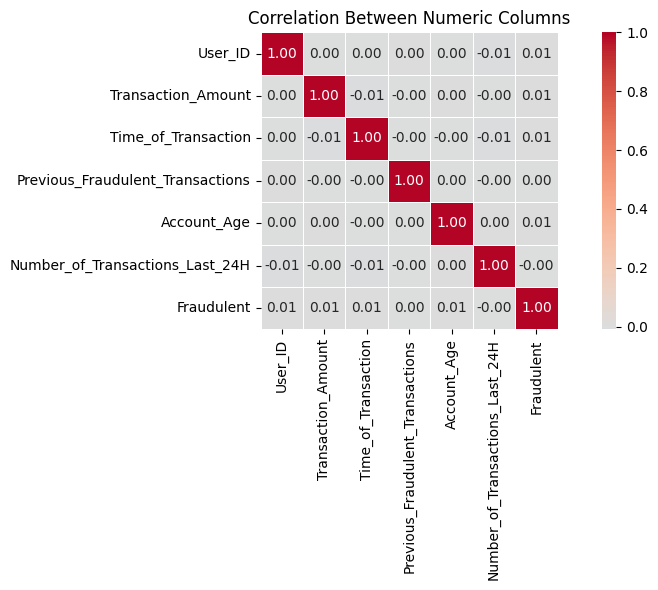

In [12]:
# Cell 10 - Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Between Numeric Columns')
plt.tight_layout()
plt.show()

In [13]:
# Cell 11 - Fix Missing Values
print("=== BEFORE CLEANING ===")
print(df.isnull().sum())

# For number columns — fill with median
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median())

# For text columns — fill with mode (most common value)
df['Device_Used'] = df['Device_Used'].fillna(df['Device_Used'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Payment_Method'] = df['Payment_Method'].fillna(df['Payment_Method'].mode()[0])

print("\n=== AFTER CLEANING ===")
print(df.isnull().sum())
print("\nMissing values remaining:", df.isnull().sum().sum())

=== BEFORE CLEANING ===
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

=== AFTER CLEANING ===
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                   

In [14]:
# Cell 12 - Encode Text Columns (convert text to numbers)
print("=== UNIQUE VALUES BEFORE ENCODING ===")
cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\n=== AFTER ENCODING (now numbers) ===")
display(df.head())

=== UNIQUE VALUES BEFORE ENCODING ===
Transaction_Type: ['ATM Withdrawal' 'Bill Payment' 'POS Payment' 'Bank Transfer'
 'Online Purchase']
Device_Used: ['Tablet' 'Mobile' 'Desktop' 'Unknown Device']
Location: ['San Francisco' 'New York' 'Boston' 'Chicago' 'Houston' 'Miami'
 'Los Angeles' 'Seattle']
Payment_Method: ['Debit Card' 'Credit Card' 'UPI' 'Net Banking' 'Invalid Method']

=== AFTER ENCODING (now numbers) ===


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,0,16.0,2,6,0,119,13,1,0
1,T2,4507,1554.58,0,13.0,1,5,4,79,3,0,0
2,T3,1860,2395.02,0,12.0,1,0,3,115,9,4,0
3,T4,2294,100.10,2,15.0,0,1,4,3,4,4,0
4,T5,2130,1490.50,4,19.0,1,6,2,57,7,0,0


In [15]:
# Cell 13 - Drop Unnecessary Columns
print("Columns before:", df.columns.tolist())

df = df.drop(columns=['Transaction_ID', 'User_ID'])

print("Columns after:", df.columns.tolist())
print("Final shape:", df.shape)

Columns before: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']
Columns after: ['Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']
Final shape: (51000, 10)


In [16]:
# Cell 14 - Final Cleaned Dataset Check
print("=== FINAL DATASET SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nFraud distribution:")
print(df['Fraudulent'].value_counts())

print("\n=== FIRST 5 ROWS OF CLEAN DATA ===")
display(df.head())

# Save cleaned dataset
df.to_csv('../data/cleaned_fraud_data.csv', index=False)
print("\nCleaned dataset saved to data/cleaned_fraud_data.csv")

=== FINAL DATASET SUMMARY ===
Shape: (51000, 10)

Missing values: 0

Fraud distribution:
Fraudulent
0    48490
1     2510
Name: count, dtype: int64

=== FIRST 5 ROWS OF CLEAN DATA ===


,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,1292.76,0,16.0,2,6,0,119,13,1,0
1,1554.58,0,13.0,1,5,4,79,3,0,0
2,2395.02,0,12.0,1,0,3,115,9,4,0
3,100.10,2,15.0,0,1,4,3,4,4,0
4,1490.50,4,19.0,1,6,2,57,7,0,0



Cleaned dataset saved to data/cleaned_fraud_data.csv
